<a href="https://colab.research.google.com/github/TaisRol/AprendizajeAutomatico2/blob/main/TP1_AA2_ROLDAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 AA1 Regreción lineal

##Alumna: Roldan Tais Maria Salomé

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

Voy a trabajar con el Dataset Estimation of Obesity Levels Based On Eating Habits and Physical Condition

In [1]:
!wget https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip
!unzip estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip

--2026-04-28 20:48:07--  https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip’

estimation+of+obesi     [ <=>                ]  56.32K  --.-KB/s    in 0.1s    

2026-04-28 20:48:08 (463 KB/s) - ‘estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip’ saved [57676]

Archive:  estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip
  inflating: ObesityDataSet_raw_and_data_sinthetic.csv  



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

Para describir las variables voy a usar df.describe (pandas) y voy a importar las librerias necesarias para poder realizar los gráficos.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [3]:
print("Variables:")
print(df.describe())

Variables:
               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000     1.000000     0.62

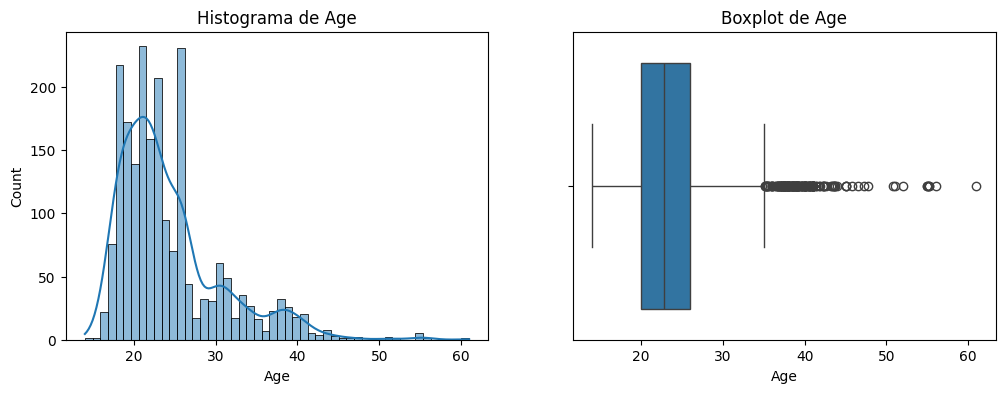

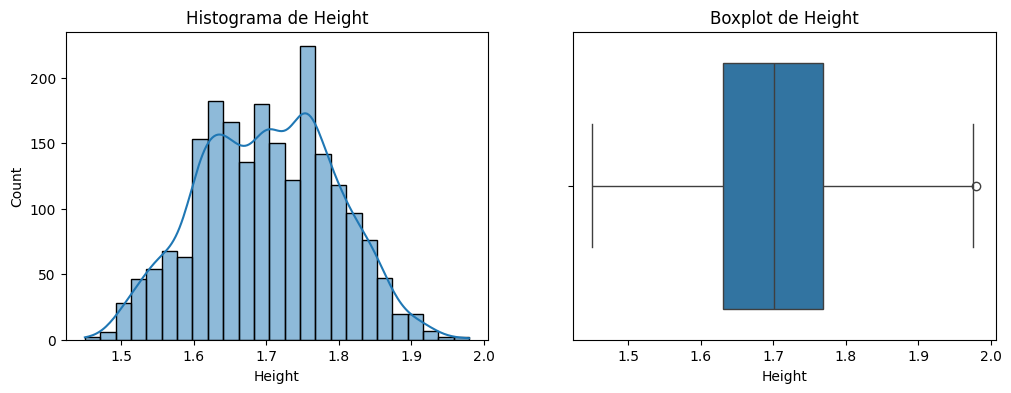

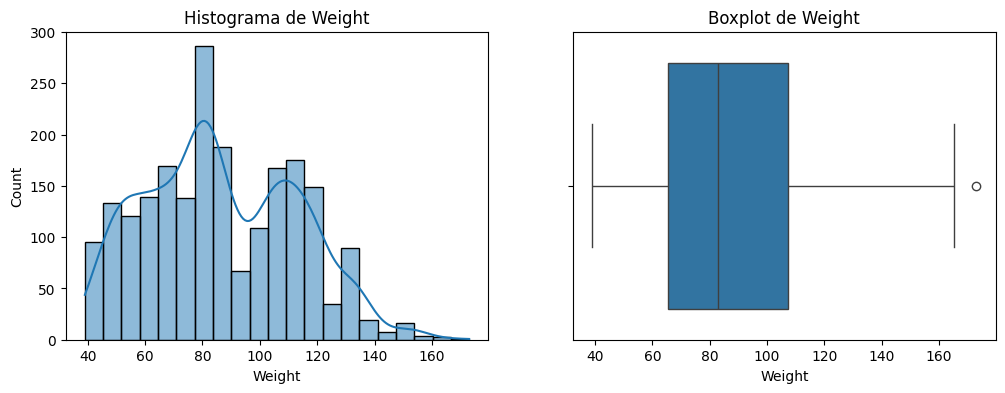

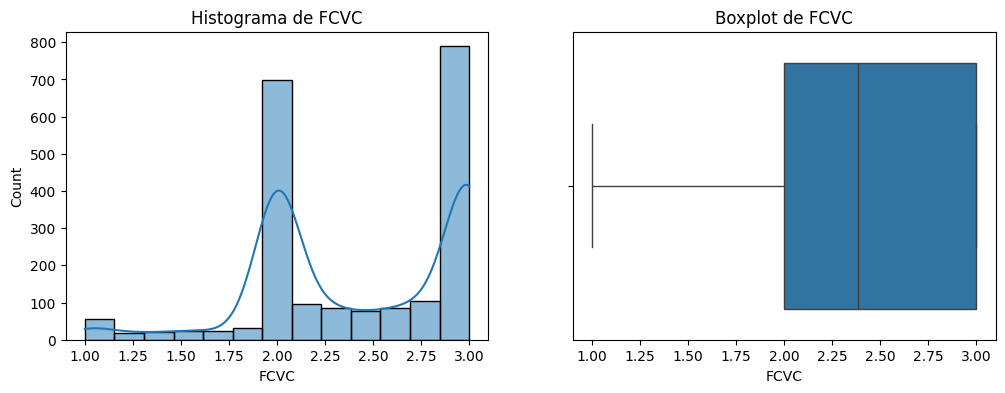

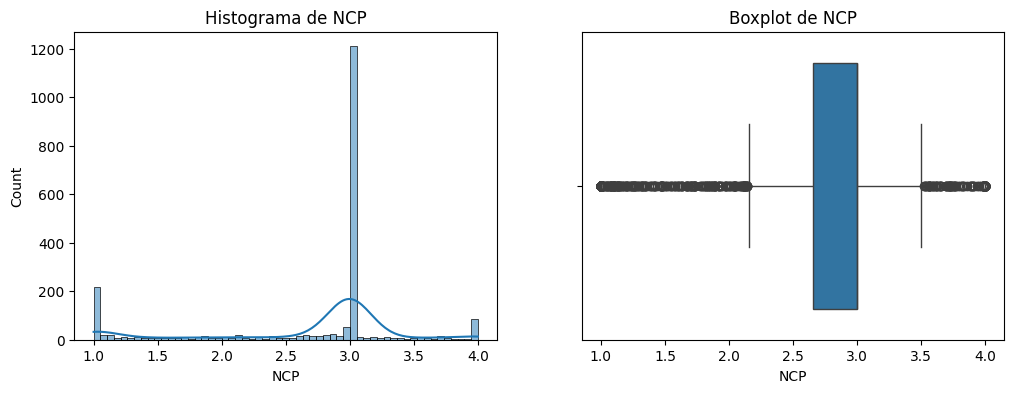

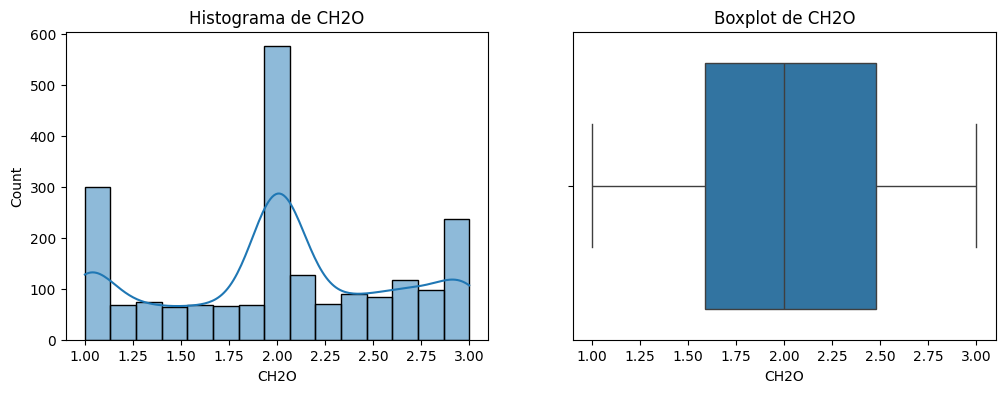

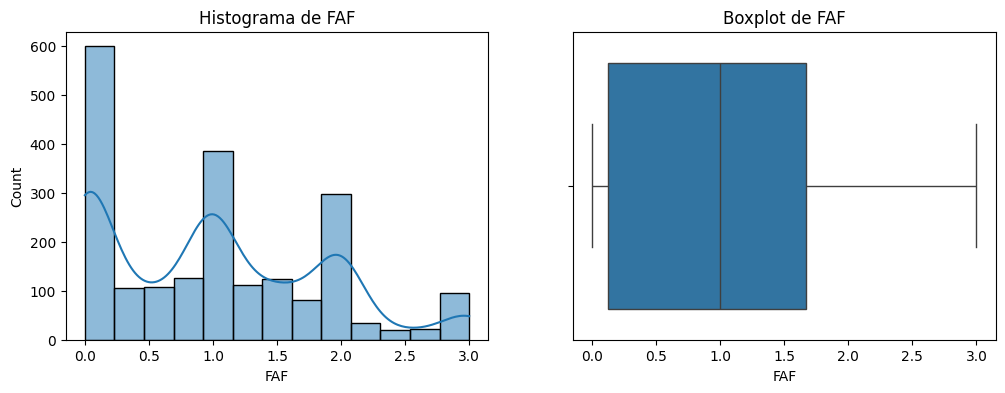

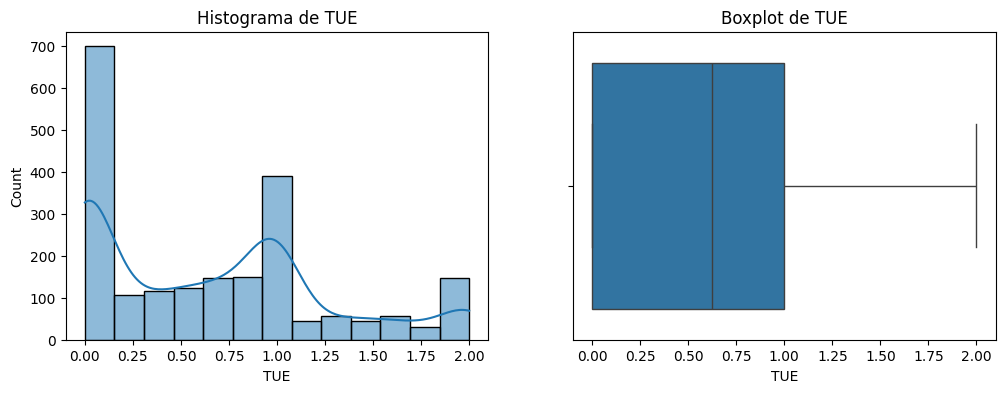

In [4]:
num_cols = df.select_dtypes(include="float64").columns #con esto solo selecciono las columnas numéricas

# Histogramas y boxplots
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histograma de {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    plt.show()

Luego pedi a Chat Gpt que me diga que representa cada variable, siendo NObeyesdad la variable target ya que esta variable representa el nivel de obesidad de una persona en base a sus características.

{0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}


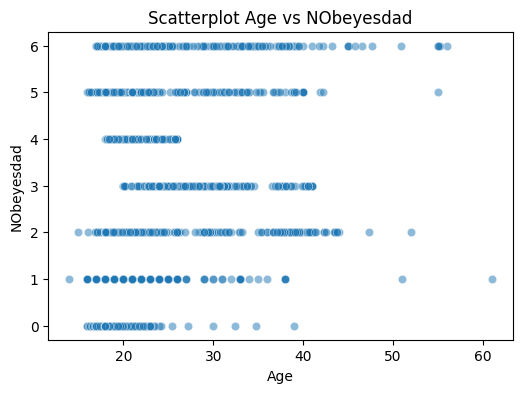

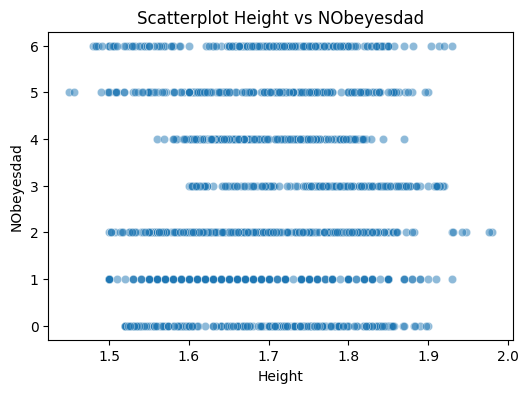

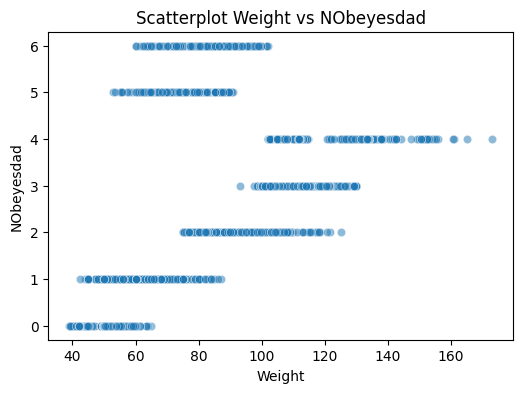

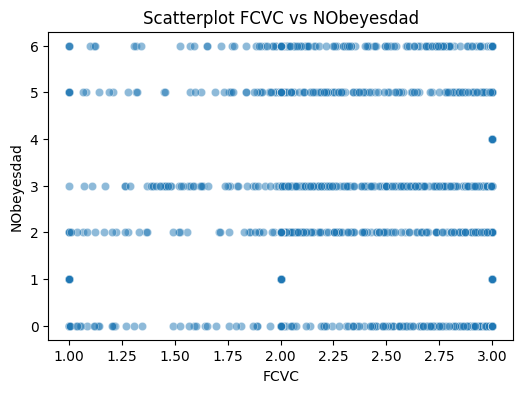

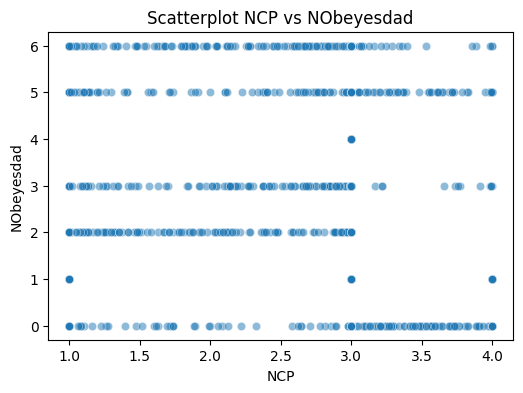

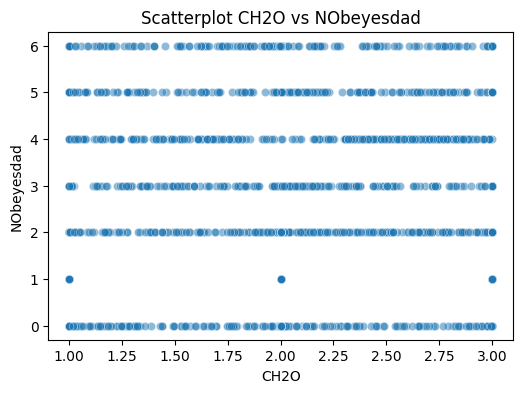

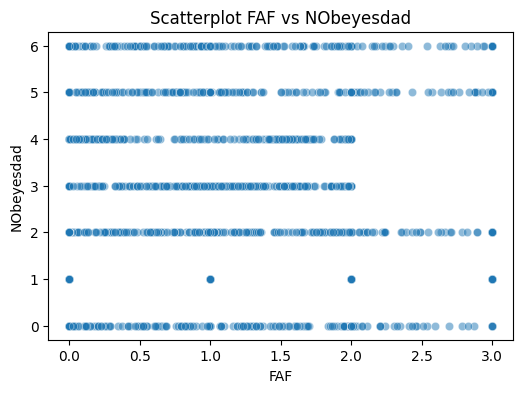

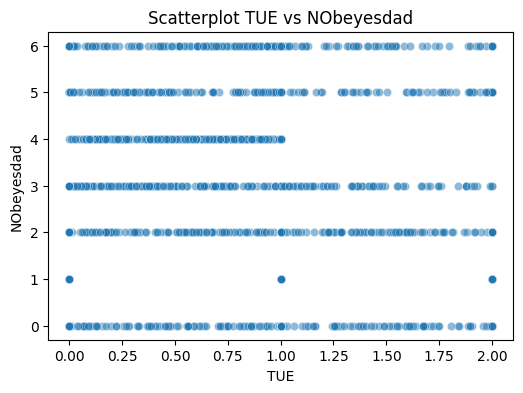

In [5]:
from sklearn.preprocessing import LabelEncoder

target = "NObeyesdad"

df_encoded = df.copy()
df_encoded[target] = LabelEncoder().fit_transform(df_encoded[target])
#esto hace que los valores del target pasen a ser numericos, y a continuacion hago que e los muestre
le = LabelEncoder()
df["NObeyesdad_encoded"] = le.fit_transform(df["NObeyesdad"])

# Mostrar el mapeo
mapping = dict(zip(df["NObeyesdad_encoded"], df["NObeyesdad"]))
mapping_sorted = dict(sorted(mapping.items()))

print(mapping_sorted)

# Graficos de dispercion
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_encoded[col], y=df_encoded[target], alpha=0.5)
    plt.title(f"Scatterplot {col} vs {target}")
    plt.show()


Relaciones preliminares entre los features y el target:

Con los features de Peso y BMI (weight e indice de masa corporal) se observa una relación positiva y casi lineal, a mayor peso o BMI, mayor la categoria de obseidad.
La altura no muesta una relación lineal conn la obesidad, significando que tanto personas altas como bajas pueden estar en ambas categorias, la distrubucion es mas dispersa y no tiene una tendencia clara.
Con la edad, hay una relación parcial, no es estrictamente lineal, aunque las categorias de obesidad mas altas tienden a concentrarse en edades intermedias-adultas.
Las variables como el consumo de comida rapida o alto contenido calorico tienden a aumentar en catgorias mas altas de obesidad.
La actividad física tiene una relación negativa con el target, los gráficos muestran que los valores altos de actividad se concentran en categorias de peso normal e insuficiente.
El tiempo frente a pantallas sugiere una relación positiva moderada porque tiende a ser más alto en personas con mayor obesidad.


## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

In [7]:
print("Valores faltantes por columna:\n", df.isnull().sum()) #si es que tiene valores faltantes, los elimina

Valores faltantes por columna:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
NObeyesdad_encoded                0
dtype: int64


Este dataset tiene pocos outliers, (en las variables peso y bmi) asi que no los voy a trabajar.

Si bien considero que todos los datos dentro del dataset son importantes, decidí eliminar la variable del historial familiar con la obesidad, ya que esta variable puede hacer que el modelo dependa demasiado de los factores heredados, restando valor al estudio de los habitos inviduales, que creo que son los mas importantes.
Y tambien decidi eliminar la columna MTRANS (metodos de transporte usados) ya que tienen baja relación directa con la obesidad.

In [8]:
df = df.drop(columns=["family_history_with_overweight", "MTRANS"], errors="ignore")
print(df.columns) #imprimimos para verificar

Index(['Gender', 'Age', 'Height', 'Weight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'NObeyesdad',
       'NObeyesdad_encoded'],
      dtype='object')


Si voy a usar variables categoricas porque tienen información clave (ej: alchool, comida rapida) y le pedi a chat GPT como trabajarlas

In [9]:
categorical_cols = df.select_dtypes(include=["object"]).columns.drop("NObeyesdad")

# One-hot encoding para categóricas nominales
df_encoded = pd.get_dummies(df, columns=categorical_cols)

In [10]:
#para el escalado
X = df_encoded.drop("NObeyesdad", axis=1)
y = df_encoded["NObeyesdad"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
#Dividir train/test
X = df_encoded.drop("NObeyesdad", axis=1)
y = df_encoded["NObeyesdad_encoded"] # Use the encoded target variable here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño train:", X_train.shape, "Tamaño test:", X_test.shape)

Tamaño train: (1688, 25) Tamaño test: (423, 25)


In [12]:
print("Columna target completa:")
print(df_encoded["NObeyesdad_encoded"].head(10))  # Primeros 10 valores
print("\nTipo:", df_encoded["NObeyesdad_encoded"].dtype)
print("\nValores únicos:", df_encoded["NObeyesdad_encoded"].unique())

Columna target completa:
0    1
1    1
2    1
3    5
4    6
5    1
6    1
7    1
8    1
9    1
Name: NObeyesdad_encoded, dtype: int64

Tipo: int64

Valores únicos: [1 5 6 2 0 3 4]





## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# PASO 1: Confirmo  Target
print("Target OK:", df_encoded["NObeyesdad_encoded"].dtype, df_encoded["NObeyesdad_encoded"].head())

# PASO 2: FUERZA X A SER NUMÉRICO
# Separa y
y = df_encoded["NObeyesdad_encoded"].values  # Numérico seguro

# Crea X excluyendo target, y filtra SOLO columnas numéricas
X_raw = df_encoded.drop("NObeyesdad_encoded", axis=1)

# IDENTIFICA Y ELIMINA COLUMNAS CON STRINGS
non_numeric_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumnas con strings detectadas (se excluyen): {non_numeric_cols}")

X = X_raw.select_dtypes(include=[np.number])  # SOLO numéricas
print(f"Forma de X (solo numéricas): {X.shape}")
print("Ejemplo de X:", X.head(1).to_dict())  # Para ver si es limpio

# PASO 3: SPLIT NUEVO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nForma X_train: {X_train.shape}, y_train: {y_train.shape}")

# PASO 4: ESCALADO (para coeficientes grandes)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("X escalado.")

# PASO 5: ENTRENA
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes (usa X.columns para nombres)
print("\nCoeficientes del modelo:")
for i, col in enumerate(X.columns):
    print(f"{col}: {model.coef_[i]}")

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Métricas train
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("\nMétricas en el set de entrenamiento:")
print(f"R²: {r2_train}")
print(f"MSE: {mse_train}")
print(f"MAE: {mae_train}")

# Métricas test
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\nMétricas en el set de testeo:")
print(f"R²: {r2_test}")
print(f"MSE: {mse_test}")
print(f"MAE: {mae_test}")

Target OK: int64 0    1
1    1
2    1
3    5
4    6
Name: NObeyesdad_encoded, dtype: int64

Columnas con strings detectadas (se excluyen): ['NObeyesdad']
Forma de X (solo numéricas): (2111, 8)
Ejemplo de X: {'Age': {0: 21.0}, 'Height': {0: 1.62}, 'Weight': {0: 64.0}, 'FCVC': {0: 2.0}, 'NCP': {0: 3.0}, 'CH2O': {0: 2.0}, 'FAF': {0: 0.0}, 'TUE': {0: 1.0}}

Forma X_train: (1688, 8), y_train: (1688,)
X escalado.

Coeficientes del modelo:
Age: 0.28471023287645497
Height: -0.2650610500231668
Weight: 0.8328723894848531
FCVC: -0.14978103566892936
NCP: -0.1944265117447519
CH2O: 0.1607575298347555
FAF: -0.11951160204445277
TUE: 0.006037748216551675

Métricas en el set de entrenamiento:
R²: 0.2226621372429486
MSE: 2.962725417907107
MAE: 1.4584478452110075

Métricas en el set de testeo:
R²: 0.19499617322688823
MSE: 3.058032857186959
MAE: 1.4953213857419736


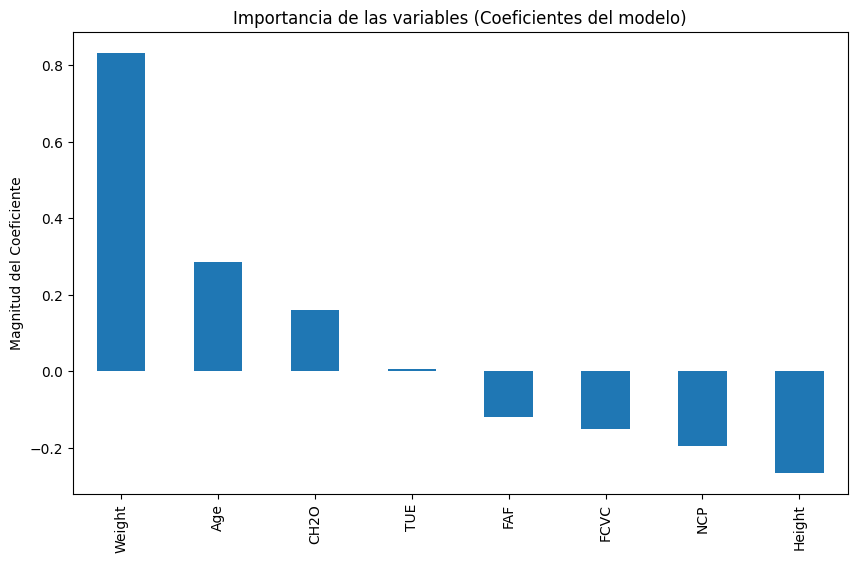

In [14]:
# Visualize coefficients
plt.figure(figsize=(10, 6))
# Use the original DataFrame's columns for the index
coefs = pd.Series(model.coef_, index=X.columns)
coefs.sort_values(ascending=False).plot(kind='bar')
plt.title("Importancia de las variables (Coeficientes del modelo)")
plt.ylabel("Magnitud del Coeficiente")
plt.show()


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

Weight es, por mucho, la variable más importante y con un efecto positivo fuerte.

Variables como Age y CH2O también tienen impacto, pero menor.

FAF, FCVC, NCP y Height tienen efectos negativos, es decir, aumentos en estas variables reducen el target.

TUE no parece relevante para el modelo.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

Las variables mas importantes del modelo son Weight (peso), Age (la edad), y CH2O, que es el consumo de agua. Que si coincide en parte con mi analisis exploratorio. El modelo no tiene un buen rendimiento y creo que es porque las relaciones entre las variables y el target no son lineales.


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  


In [15]:
!wget

wget: missing URL
Usage: wget [OPTION]... [URL]...

Try `wget --help' for more options.


#TP1 MLP Aprendizaje Automático 2

##2.1) Resuelva su problema creando su propia red neuronal con Pytorch. Para ello debe crear una clase que herede de nn.Module y especificar su arquitectura. Justifique

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ObesityClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=7):
        """
        input_dim: Número de columnas después del preprocesamiento (ej. 23)
        hidden_dim: Número de neuronas en la primera capa oculta (ajustable para el experimento)
        output_dim: 7 clases correspondientes a los niveles de obesidad
        """
        super(ObesityClassifier, self).__init__()

        # Capa de entrada hacia la primera capa oculta
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Capa oculta intermedia (reduce a la mitad para concentrar la información)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)

        # Capa de salida hacia las 7 clases
        self.fc3 = nn.Linear(hidden_dim // 2, output_dim)

        # Dropout para regularización (apaga neuronas al azar para evitar que memoricen)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Aplicamos la función de activación ReLU después de cada capa oculta
        x = F.relu(self.fc1(x))
        x = self.dropout(x) # Aplicamos dropout durante el entrenamiento

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # La última capa NO lleva función de activación
        # porque la función de pérdida CrossEntropyLoss de PyTorch la incluye internamente.
        x = self.fc3(x)

        return x

Para empezar, utilicé 3 capaz lineales (nn.linear). la primera recibe los datos preprocesados, la segunda comprime la dimención a la mitad (asi el modelo usa los datos más importantes) y la tercera proyecta el resultado final en 7 neuronas, cad una corresponde a cada nivel de obesidad.

El Dropout al 30% regula y previene el sobreajuste, este apaga neuronas aleatoriamente durante el entrenamiento.

##2.2) Entrene dicha red, evalue métricas correspondientes en conjuntos de entrenamiento y testeo.

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

# 1.1 Codificación de variables
# Variables explicativas (X): One-Hot Encoding para categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.drop('NObeyesdad')
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Variable objetivo (y): Label Encoding (0 a 6)
le = LabelEncoder()
df_processed['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

X = df_processed.drop('NObeyesdad', axis=1).values
y = df_processed['NObeyesdad'].values

# 1.2 División y Escalamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1.3 Conversión a Tensores de PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

# Creamos un DataLoader para manejar los lotes (batches)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

Para el preprosesamiento aplique Label Encoding, haciendo que la variable objetivo pase de ser de 0 a 6.
Luego de dividir el dataset en entrenamiento/prueba realicé un escalado para que las variables predictoras tengan media 0 y varianza 1.

In [18]:
# Configuración inicial
input_dim = X_train.shape[1]
model = ObesityClassifier(input_dim=input_dim, hidden_dim=64, output_dim=7)
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Bucle de entrenamiento
epochs = 60
for epoch in range(epochs):
    model.train()
    for inputs, labels in train_loader:
        optimizer.zero_grad()   # Limpiar gradientes anteriores
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()         # Backward pass (cálculo de gradientes)
        optimizer.step()        # Actualización de pesos

    if (epoch + 1) % 10 == 0:
        print(f'Época [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Época [10/60], Loss: 0.4809
Época [20/60], Loss: 0.3640
Época [30/60], Loss: 0.2458
Época [40/60], Loss: 0.4155
Época [50/60], Loss: 0.1531
Época [60/60], Loss: 0.1089


Tendencia de Convergencia: El valor de la función de pérdida (CrossEntropyLoss) muestra una reducción general significativa, comenzando en 0.4809 (Época 10) y finalizando en un excelente 0.1089 (Época 60). Esta caída sostenida confirma que la arquitectura es correcta y que el algoritmo de retropropagación está ajustando exitosamente los pesos para minimizar las clasificaciones erróneas.

In [19]:
def evaluar_modelo(X_tensor, y_true, nombre_set):
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        _, predictions = torch.max(outputs, 1)
        print(f"\n--- Métricas en {nombre_set} ---")
        print(classification_report(y_true, predictions.numpy(), target_names=le.classes_))

# Ejecutar evaluación
evaluar_modelo(X_train_t, y_train, "Entrenamiento")
evaluar_modelo(X_test_t, y_test, "Testeo")


--- Métricas en Entrenamiento ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98       218
      Normal_Weight       0.98      0.96      0.97       229
     Obesity_Type_I       1.00      1.00      1.00       281
    Obesity_Type_II       1.00      1.00      1.00       237
   Obesity_Type_III       1.00      1.00      1.00       259
 Overweight_Level_I       0.98      0.98      0.98       232
Overweight_Level_II       1.00      0.98      0.99       232

           accuracy                           0.99      1688
          macro avg       0.99      0.99      0.99      1688
       weighted avg       0.99      0.99      0.99      1688


--- Métricas en Testeo ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        54
      Normal_Weight       0.91      0.86      0.88        58
     Obesity_Type_I       0.93      0.97      0.95        70
    Obesity_Type_I

El modelo es prácticamente infalible al detectar los casos más extremos. La clase Obesity_Type_III alcanzó un F1-Score del 0.99, y Obesity_Type_II un 0.96. Esto ocurre porque las características de estos pacientes (índice de masa corporal muy alto, ciertos hábitos muy marcados) crean un clúster matemático muy separado y fácil de identificar para la red neuronal.

##2.3) Realice un experimento para mostrar como variando el número de neuronas ( o capas), graficar las curvas de error en entrenamiento y testeo, para observar zonas de subajuste y sobreajuste. Redacte sus conclusiones y análisis.

In [20]:
def train_and_evaluate(hidden_neurons, epochs=80):
    model = ObesityClassifier(input_dim=input_dim, hidden_dim=hidden_neurons, output_dim=7)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # --- Fase de Entrenamiento ---
        model.train()
        batch_losses = []
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_losses.append(np.mean(batch_losses))

        # --- Fase de Testeo ---
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_t)
            test_loss = criterion(test_outputs, y_test_t)
            test_losses.append(test_loss.item())

    return train_losses, test_losses

Entrenando red con 4 neuronas ocultas...
Entrenando red con 64 neuronas ocultas...
Entrenando red con 512 neuronas ocultas...


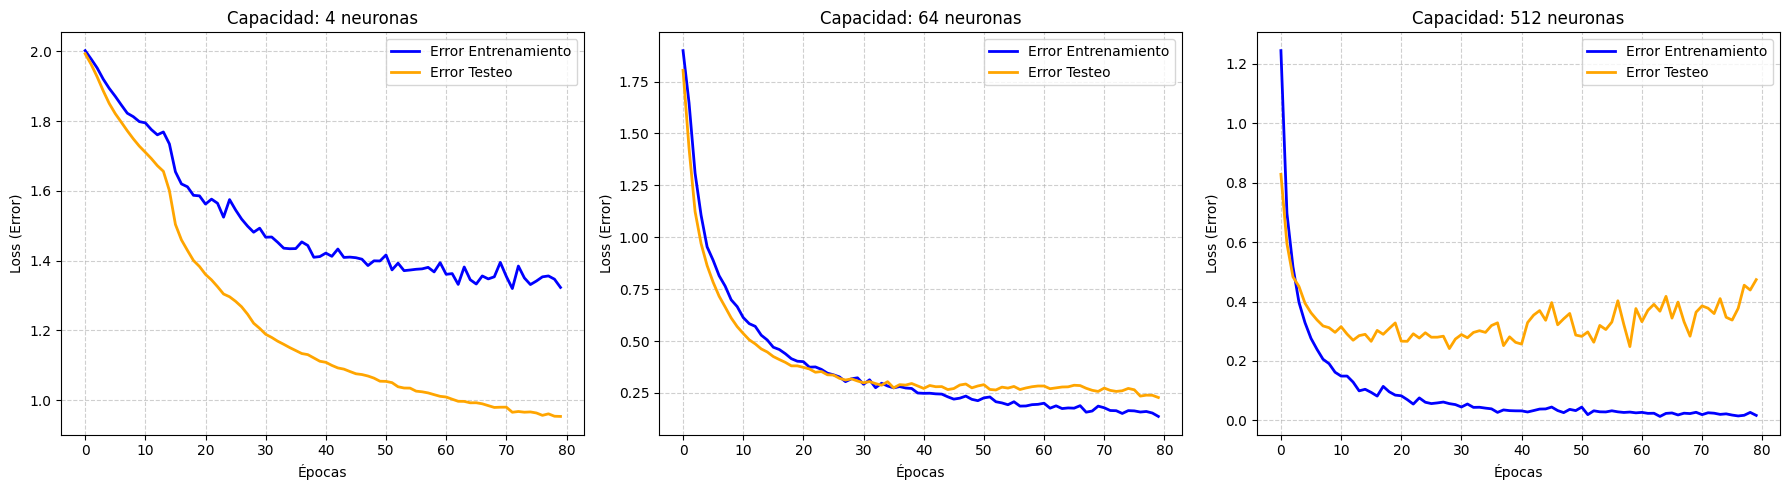

¡Experimento finalizado!


In [21]:
escenarios_neuronas = [4, 64, 512]

plt.figure(figsize=(18, 5))

for i, neurons in enumerate(escenarios_neuronas):
    print(f"Entrenando red con {neurons} neuronas ocultas...")
    train_loss, test_loss = train_and_evaluate(neurons, epochs=80)

    # Dibujar gráfico
    plt.subplot(1, 3, i+1)
    plt.plot(train_loss, label='Error Entrenamiento', color='blue', linewidth=2)
    plt.plot(test_loss, label='Error Testeo', color='orange', linewidth=2)
    plt.title(f'Capacidad: {neurons} neuronas')
    plt.xlabel('Épocas')
    plt.ylabel('Loss (Error)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
print("¡Experimento finalizado!")

* En estos g´raficos podemos observar:
En el primero, como tanto el entrenamiento como el testeo  son altos, la cantidad de neuronas es poca para el modelo, lo que genero un claro underfitting, y a consecuencia el modelo no tiene suficiente capacidad para captar la estructura de los datos.

* En el de 64 neuronas podemos ver como el error baja rápido y se estabiliza, el error del test es ligeramente mayor al de entrenamiento, lo que significa que tiene un buen equilibrio (aprende patrones relevantes sin sobreajustar), es el modelo que mejor generaliza.

* En este gráfico con 512 neuronas se puede observar un overfitting claro, ya que el error de entrenamiento cae cerca de 0 y el error de test baja al principio pero luego sube. Esto significa que el modelo memoriza el entrenamiento (overfitting).

##2.4) Compare la configuración elegida con el desempeño de los modelos de aprendizaje automático que haya usado en ese mismo notebook en AA1

Cuando use el modelo de regresión para este mismo dataset, lo que ocurrió fue que tuve malas metricas, el modelo tuvo un desempeño pobre ya que
1ro. estaba mal ejecutado y 2do lo óptimo hubiese sido que se realice un metodo de clasificación, no de regresión. En cambio cuando lo trabajé ahora que realicé el trabajo de clásificación, las metricas fueron perfectas.